Populando

In [11]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [38]:
OUTPUT_DIR = Path('../data')

cardinali = pd.read_csv(OUTPUT_DIR / 'cardinali.csv')
roca = pd.read_csv(OUTPUT_DIR / 'roca.csv')
center = pd.read_csv(OUTPUT_DIR / 'center.csv')
abias = pd.read_csv(OUTPUT_DIR / 'abias.csv')
sape = pd.read_csv(OUTPUT_DIR / 'sape.csv')

df = pd.concat([cardinali, roca, center, abias, sape], ignore_index=True)

print(f'cardinali: {len(cardinali)} linhas')
print(f'roca:      {len(roca)} linhas')
print(f'center:    {len(center)} linhas')
print(f'abias:     {len(abias)} linhas')
print(f'sape:      {len(sape)} linhas')
print(f'total:     {len(df)} linhas')
df.head(1)


cardinali: 4232 linhas
roca:      2438 linhas
center:    678 linhas
abias:     274 linhas
sape:      1035 linhas
total:     8657 linhas


,fonte,codigo,titulo,tipo,subtipo,finalidade,preco_locacao,preco_venda,valor_condominio,valor_iptu,...,banheiros,garagens,area_total,area_construida,area_util,area_terreno,descricao,url,latitude,longitude
0,Cardinali,237897,Valor do aluguel está incluso condômino e IPTU,Apartamento,Padrao,Locacao,"1.112,00",NaN,",",.,...,1.0,1.0,NaN,NaN,50.0,NaN,Valor do aluguel está incluso condômino e IPTU...,https://www.cardinali.com.br/alugar/Sao-Carlos...,-22.026474,-47.917273


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8657 entries, 0 to 8656
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fonte             8657 non-null   str    
 1   codigo            8657 non-null   int64  
 2   titulo            8029 non-null   str    
 3   tipo              8657 non-null   str    
 4   subtipo           7348 non-null   object 
 5   finalidade        7745 non-null   str    
 6   preco_locacao     4440 non-null   str    
 7   preco_venda       4446 non-null   object 
 8   valor_condominio  6154 non-null   object 
 9   valor_iptu        4974 non-null   object 
 10  bairro            8642 non-null   str    
 11  cidade            8657 non-null   str    
 12  estado            8653 non-null   str    
 13  endereco          0 non-null      float64
 14  dormitorios       5806 non-null   float64
 15  suites            2734 non-null   float64
 16  banheiros         7230 non-null   float64
 17  garage

In [14]:
df.describe()

,codigo,endereco,dormitorios,suites,banheiros,garagens,area_total,area_construida,area_util,area_terreno,latitude,longitude
count,8657.000000,0.0,5806.000000,2734.000000,7230.000000,5682.000000,3277.000000,3411.000000,4540.000000,1729.000000,7322.000000,7322.000000
mean,117037.392053,NaN,2.288322,17.688793,1.728216,2.222985,1339.249665,242.803802,171.354963,1298.345379,-21.995564,-47.864838
std,85671.497140,NaN,1.114106,230.119676,1.446273,3.036261,16334.091025,924.958773,718.385371,6247.431508,0.851224,1.354879
min,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.500000,-23.824286,-92.927450
25%,36781.000000,NaN,2.000000,0.000000,1.000000,1.000000,40.000000,45.000000,40.000000,150.000000,-22.023032,-47.902220
50%,87676.000000,NaN,2.000000,1.000000,1.000000,2.000000,69.000000,73.700000,56.000000,250.000000,-22.014715,-47.892932
75%,206993.000000,NaN,3.000000,1.000000,2.000000,2.000000,250.000000,184.000000,127.000000,363.600000,-22.000225,-47.883450
max,237898.000000,NaN,11.000000,10000.000000,40.000000,55.000000,720000.000000,23846.000000,24200.000000,55000.000000,17.989620,0.000000


Pre processamento

In [39]:
df.columns = df.columns.str.lower().str.strip()

colunas_texto = ["tipo", "subtipo", "finalidade", "bairro", "cidade", "estado", "fonte"]
for coluna in colunas_texto:
    if coluna in df.columns:
        df[coluna] = df[coluna].astype(str).str.lower().str.strip()
        df[coluna] = df[coluna].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

subs = {r'\bjd\b': 'jardim', r'\bj\b': 'jardim', r'\bpq\b': 'parque',
        r'\bvl\b': 'vila', r'\bres\b': 'residencial', r'\bcond\b': 'condominio', r'\bch\b': 'chacara'}
df['bairro'] = df['bairro'].replace(subs, regex=True)
df['bairro'] = df['bairro'].str.replace(r'\s+', ' ', regex=True).str.strip()

if 'finalidade' in df.columns:
    df = df[df["finalidade"] == "locacao"]

if 'tipo' in df.columns:
    df['tipo'] = df['tipo'].replace({'apartamentos': 'apartamento', 'casas': 'casa'})
    df = df[df['tipo'].isin(['apartamento', 'casa'])]

print(f"Filtro tipo/finalidade: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro tipo/finalidade: 2000 linhas
  roca        : 765 linhas
  cardinali   : 521 linhas
  center      : 306 linhas
  sape        : 206 linhas
  abias       : 202 linhas


In [40]:
# === DIAGNÓSTICO: onde cada linha é perdida na limpeza ===
diag = df.copy()
total_inicio = len(diag)

# Parsear valores monetários (ainda são strings neste ponto)
def _parse(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao', 'valor_condominio', 'valor_iptu']:
    if col in diag.columns: diag[col] = diag[col].apply(_parse)
for col in ['area_util', 'area_construida', 'area_total']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')
for col in ['latitude', 'longitude']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')

diag.loc[diag['latitude'] == 0, 'latitude'] = np.nan
diag.loc[diag['longitude'] == 0, 'longitude'] = np.nan

# Fallback de área (mesmo do pipeline)
if 'area_util' in diag.columns:
    diag['area_util'] = diag['area_util'].fillna(diag.get('area_construida')).fillna(diag.get('area_total'))

filtros = {
    'lat/lon nulo': diag[['latitude','longitude']].isna().any(axis=1),
    'fora bounding box SC': diag['latitude'].notna() & diag['longitude'].notna() & ~(diag['latitude'].between(-22.1, -21.9) & diag['longitude'].between(-48.05, -47.8)),
    'preco_locacao nulo': diag['preco_locacao'].isna(),
    'bairro nulo': diag['bairro'].isna(),
    'area_util nula': diag['area_util'].isna(),
    'preco_locacao <= 0': (diag['preco_locacao'] <= 0) & diag['preco_locacao'].notna(),
    'area_util <= 5': (diag['area_util'] <= 5) & diag['area_util'].notna(),
    'apt area > 500': (diag['tipo'] == 'apartamento') & (diag['area_util'] > 500),
    'casa area > 2000': (diag['tipo'] == 'casa') & (diag['area_util'] > 2000),
    'preco > 15000': (diag['preco_locacao'] > 15000) & diag['preco_locacao'].notna(),
    'condominio > 5000': (diag['valor_condominio'] > 5000) & diag['valor_condominio'].notna(),
    'garagens > 6': diag['garagens'] > 6 if 'garagens' in diag.columns else pd.Series(False, index=diag.index),
}

print(f"Total antes da limpeza: {total_inicio} linhas\n")
print(f"{'Filtro':<25s} {'Afetados':>8s}  {'%':>6s}  Por fonte")
print("-" * 90)
for nome, mask in filtros.items():
    n = mask.sum()
    if n > 0:
        por_fonte = diag.loc[mask, 'fonte'].value_counts()
        fonte_str = ', '.join(f"{f}:{q}" for f, q in por_fonte.items())
        print(f"  {nome:<23s} {n:>8d}  {n/total_inicio*100:>5.1f}%  {fonte_str}")

any_filter = pd.DataFrame(filtros).any(axis=1)
print(f"\n  {'Eliminadas (qualquer)':23s} {any_filter.sum():>8d}  {any_filter.sum()/total_inicio*100:>5.1f}%")
print(f"  {'Sobrevivem':23s} {(~any_filter).sum():>8d}  {(~any_filter).sum()/total_inicio*100:>5.1f}%")


Total antes da limpeza: 2000 linhas

Filtro                    Afetados       %  Por fonte
------------------------------------------------------------------------------------------
  lat/lon nulo                 269   13.5%  roca:68, sape:68, center:61, cardinali:40, abias:32
  fora bounding box SC          19    0.9%  sape:15, cardinali:2, roca:2
  area_util nula               459   22.9%  cardinali:305, sape:140, roca:8, center:4, abias:2
  area_util <= 5                93    4.7%  center:91, roca:1, sape:1
  apt area > 500                 1    0.1%  center:1
  casa area > 2000               1    0.1%  center:1
  preco > 15000                 10    0.5%  cardinali:4, roca:4, abias:1, sape:1
  condominio > 5000            155    7.8%  roca:96, center:55, cardinali:4
  garagens > 6                  23    1.1%  roca:10, cardinali:6, sape:4, center:2, abias:1

  Eliminadas (qualquer)        855   42.8%
  Sobrevivem                  1145   57.2%


In [14]:
def parse_br_money(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao', 'valor_condominio', 'valor_iptu']:
    if col in df.columns: df[col] = df[col].apply(parse_br_money)

for col in ['area_util', 'area_construida', 'area_total']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['dormitorios', 'banheiros', 'garagens']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

if 'suites' in df.columns:
    df['suites'] = pd.to_numeric(df['suites'], errors='coerce').fillna(0).astype(int)

if 'latitude' in df.columns: df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
if 'longitude' in df.columns: df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.loc[df['latitude'] == 0, 'latitude'] = np.nan
df.loc[df['longitude'] == 0, 'longitude'] = np.nan
df = df.dropna(subset=['latitude', 'longitude'])

# Bounding box São Carlos - remove coordenadas fora da região
df = df[
    (df['latitude'].between(-22.1, -21.9)) &
    (df['longitude'].between(-48.05, -47.8))
]

if 'area_util' in df.columns:
    df['area_util'] = df['area_util'].fillna(df.get('area_construida')).fillna(df.get('area_total'))

df = df.dropna(subset=['preco_locacao', 'bairro', 'area_util'])
df = df[(df['preco_locacao'] > 0) & (df['area_util'] > 5)]
df = df[~((df['tipo'] == 'apartamento') & (df['area_util'] > 500))]
df = df[~((df['tipo'] == 'casa') & (df['area_util'] > 2000))]

# Remove valores absurdos
df = df[df['preco_locacao'] <= 15000]
df = df[df['valor_condominio'].isna() | (df['valor_condominio'] <= 5000)]
df = df[df['valor_iptu'].isna() | (df['valor_iptu'] <= 5000)]
df = df[df['garagens'] <= 6]
df = df[df['area_util'] <= 500]

# Imputação Condomínio
if 'valor_condominio' in df.columns:
    df['valor_condominio'] = df['valor_condominio'].replace(0, np.nan)
    mask_apt = (df['tipo'] == 'apartamento')
    df.loc[mask_apt, 'valor_condominio'] = df.loc[mask_apt, 'valor_condominio'].fillna(
        df[mask_apt].groupby('bairro')['valor_condominio'].transform('median')
    )
    df.loc[mask_apt, 'valor_condominio'] = df.loc[mask_apt, 'valor_condominio'].fillna(df.loc[mask_apt, 'valor_condominio'].median())
    df['valor_condominio'] = df['valor_condominio'].fillna(0)

# Imputação IPTU
if 'valor_iptu' in df.columns:
    df['valor_iptu'] = df['valor_iptu'].replace(0, np.nan)
    df['valor_iptu'] = df['valor_iptu'].fillna(df.groupby('bairro')['valor_iptu'].transform('median')).fillna(0)

print(f"Limpeza + imputação: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Limpeza + imputação: 1063 linhas
  roca        : 530 linhas
  cardinali   : 205 linhas
  abias       : 167 linhas
  center      : 121 linhas
  sape        : 40 linhas


In [15]:
desc = df['descricao'].fillna('').astype(str).str.lower() if 'descricao' in df.columns else pd.Series('', index=df.index)

# Features de texto
df['foco_estudante'] = desc.str.contains('estudante|republica|caaso|federal|kitnet|republicas', regex=True).astype(int)
df['reformado_novo'] = desc.str.contains('reformado|novo|primeira locacao|recem', regex=True).astype(int)
df['mobiliado'] = desc.str.contains('mobiliado|mobilhado|mobilia', regex=True).astype(int)
df['piscina'] = desc.str.contains('piscina', regex=True).astype(int)
df['churrasqueira'] = desc.str.contains('churrasqueira|churrasq', regex=True).astype(int)

df['cond_por_m2'] = (df['valor_condominio'] / df['area_util']).replace([np.inf, -np.inf], 0).fillna(0)
df['total_comodos'] = df['dormitorios'] + df['banheiros']
df['area_por_quarto'] = (df['area_util'] / df['dormitorios'].clip(lower=1))

if 'latitude' in df.columns and 'longitude' in df.columns:
    KM_DEGREE = 111 
    CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
    UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
    USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
    RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

    df['dist_centro'] = np.sqrt((df['latitude'] - CENTRO_LAT)**2 + (df['longitude'] - CENTRO_LON)**2) * KM_DEGREE
    df['dist_ufscar'] = np.sqrt((df['latitude'] - UFSCAR_LAT)**2 + (df['longitude'] - UFSCAR_LON)**2) * KM_DEGREE
    df['dist_usp'] = np.sqrt((df['latitude'] - USP_CAMPUS1_LAT)**2 + (df['longitude'] - USP_CAMPUS1_LON)**2) * KM_DEGREE
    df['dist_rodoviaria'] = np.sqrt((df['latitude'] - RODOVIARIA_LAT)**2 + (df['longitude'] - RODOVIARIA_LON)**2) * KM_DEGREE

    colunas_dist = ['dist_centro', 'dist_ufscar', 'dist_usp', 'dist_rodoviaria']
    df[colunas_dist] = df[colunas_dist].fillna(df[colunas_dist].median())

contagem = df['bairro'].value_counts()
df.loc[~df['bairro'].isin(contagem[contagem >= 5].index), 'bairro'] = 'outros'
df = df.drop_duplicates(subset=['preco_locacao', 'bairro', 'area_util', 'dormitorios', 'banheiros', 'tipo'])

print(f"Features + dedup: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Features + dedup: 980 linhas
  roca        : 486 linhas
  cardinali   : 191 linhas
  abias       : 160 linhas
  center      : 112 linhas
  sape        : 31 linhas


In [16]:
# O filtro robusto usando o pacote total
df['preco_total_temp'] = df['preco_locacao'] + df['valor_condominio'] + df['valor_iptu']
df['preco_m2_temp'] = df['preco_total_temp'] / df['area_util']
Q_low, Q_high = df['preco_m2_temp'].quantile(0.02), df['preco_m2_temp'].quantile(0.98)

df = df[(df['preco_m2_temp'] >= Q_low) & (df['preco_m2_temp'] <= Q_high)]

# Limpa colunas temporárias
df = df.drop(columns=['preco_total_temp', 'preco_m2_temp'])

print(f"Filtro percentil: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro percentil: 940 linhas
  roca        : 471 linhas
  cardinali   : 182 linhas
  abias       : 158 linhas
  center      : 99 linhas
  sape        : 30 linhas


In [19]:
colunas_exibir = ['tipo', 'bairro', 'preco_locacao', 'area_util', 'dormitorios', 'banheiros', 
                  'garagens', 'valor_condominio', 'valor_iptu', 'latitude', 'longitude',
                  'foco_estudante', 'reformado_novo', 'cond_por_m2', 'total_comodos', 
                  'area_por_quarto', 'dist_centro', 'dist_ufscar', 'dist_usp']
df[[c for c in colunas_exibir if c in df.columns]].describe()

,preco_locacao,area_util,dormitorios,banheiros,garagens,valor_condominio,valor_iptu,latitude,longitude,foco_estudante,reformado_novo,cond_por_m2,total_comodos,area_por_quarto,dist_centro,dist_ufscar,dist_usp
count,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,2179.361543,89.127372,2.115957,1.215957,1.241489,1198.536059,657.182309,-22.009662,-47.895580,0.085106,0.152128,22.998828,3.331915,41.046379,2.345716,3.895545,2.194689
std,1420.850807,70.833629,0.899864,0.888430,1.049459,1533.804558,906.373806,0.016546,0.016829,0.279188,0.359336,29.439514,1.451540,27.140308,1.541046,1.437048,1.480557
min,400.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-22.060610,-47.949024,0.000000,0.000000,0.000000,1.000000,10.000000,0.118853,0.948156,0.044400
25%,1334.000000,45.000000,2.000000,1.000000,1.000000,0.000000,94.000000,-22.022019,-47.904100,0.000000,0.000000,0.000000,2.000000,25.000000,1.407480,2.725246,1.093187
50%,1778.000000,60.000000,2.000000,1.000000,1.000000,350.000000,370.000000,-22.009320,-47.895065,0.000000,0.000000,6.666667,3.000000,32.583333,2.032594,3.812589,1.859627
75%,2556.000000,106.250000,3.000000,2.000000,2.000000,2300.000000,819.000000,-22.000210,-47.887288,0.000000,0.000000,49.018519,4.000000,48.362500,2.784333,4.823259,2.965913
max,12000.000000,450.000000,6.000000,6.000000,6.000000,5000.000000,4933.000000,-21.953790,-47.804437,1.000000,1.000000,131.428571,11.000000,400.000000,10.640221,8.984805,10.565023


In [17]:
remover = ['area_construida', 'endereco', 'codigo', 'area_terreno', 'url', 'area_total', 'estado', 'cidade']

# Agora vai funcionar!
df.drop(columns=remover, inplace=True, errors='ignore')

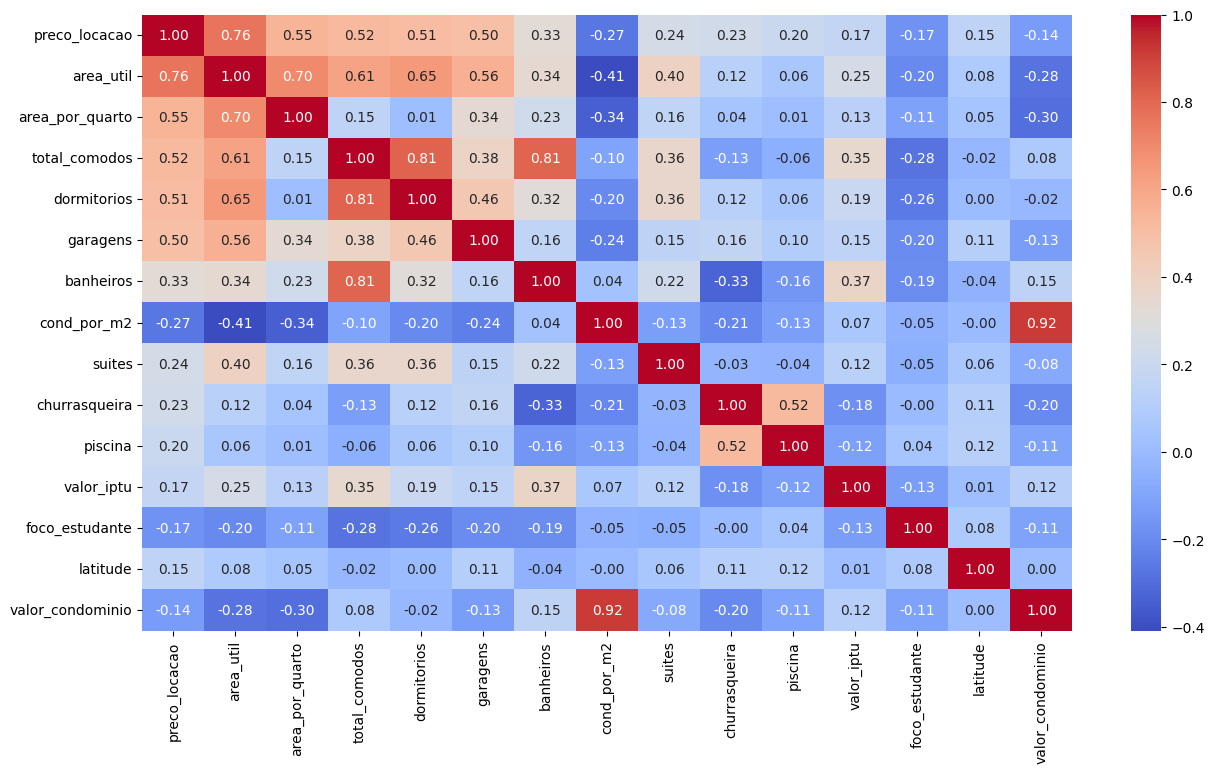

In [26]:
# Calcula a correlação de todas as numéricas
correlacao = df.corr(numeric_only=True)

# Pega as 10 colunas com maior correlação com 'preco_locacao' 
# (pegando os valores absolutos para considerar correlações negativas fortes também)
top_colunas = correlacao['preco_locacao'].abs().nlargest(15).index

# Aumenta o tamanho da figura
plt.figure(figsize=(15, 8))

# Plota o heatmap APENAS dessas 10 colunas
sns.heatmap(df[top_colunas].corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [22]:
df.iloc[0]

fonte                                                       cardinali
titulo                 Valor do aluguel está incluso condômino e IPTU
tipo                                                      apartamento
subtipo                                                        padrao
finalidade                                                    locacao
preco_locacao                                                  1112.0
preco_venda                                                       NaN
valor_condominio                                               1100.0
valor_iptu                                                      215.0
bairro                                                  romeu santini
dormitorios                                                         2
suites                                                              0
banheiros                                                           1
garagens                                                            1
area_util           

In [18]:
features_limpas = [
    'tipo', 'area_util', 'bairro', 'area_por_quarto', 'dist_centro', 
    'dist_ufscar', 'dist_usp', 'dist_rodoviaria', 'garagens', 
    'total_comodos', 'dormitorios', 'banheiros', 'suites', 'reformado_novo', 
    'foco_estudante', 
    'latitude', 'longitude'
]

X = df[features_limpas].copy()
y = df['preco_locacao'].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('bairro_enc', TargetEncoder(random_state=42), ['bairro']),
        ('tipo_enc', TargetEncoder(random_state=42), ['tipo']),
    ],
    remainder='passthrough'
)

In [24]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(
            n_estimators=300, 
            learning_rate=0.05, 
            max_depth=7, 
            num_leaves=31, 
            random_state=42, 
            n_jobs=-1,
            objective='mae',
            verbose=-1
        ),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res = cross_validate(pipe, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"LightGBM - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 499.56
MAE Folds: [497.57 504.23 523.93 542.69 429.38]
------------------------------------------------------------
R² Médio:  0.662
R² Folds:  [0.632 0.557 0.724 0.688 0.711]


/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [20]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'objective': 'mae',
        'verbose': -1,
    }

    pipe_opt = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=LGBMRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipe_opt, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=150, show_progress_bar=True)

print("="*60)
print("Melhores hiperparâmetros encontrados:")
print("-" * 60)
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study.best_value:.2f}")
print("="*60)

  0%|          | 0/150 [00:00<?, ?it/s]/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning

Melhores hiperparâmetros encontrados:
------------------------------------------------------------
  n_estimators          : 1991
  learning_rate         : 0.04828592179164016
  max_depth             : 10
  num_leaves            : 24
  min_child_samples     : 8
  subsample             : 0.9713298453457873
  colsample_bytree      : 0.5176163556437088
  reg_alpha             : 0.06674474540654841
  reg_lambda            : 0.0015735540031049519

Melhor MAE: R$ 473.71


In [ ]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': 42,
        'n_jobs': -1,
    }

    pipe_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=RandomForestRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipe_rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=150, show_progress_bar=True)

print("="*60)
print("Random Forest - Melhores hiperparâmetros:")
print("-" * 60)
for k, v in study_rf.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study_rf.best_value:.2f}")
print("="*60)

NameError: name 'optuna' is not defined

In [ ]:
best_rf = study_rf.best_params
best_rf.update({'random_state': 42, 'n_jobs': -1})

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(**best_rf),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_rf = cross_validate(pipe_rf, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_rf['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_rf['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_rf['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_rf['test_r2'], 3)}")
print("="*60)

Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 489.10
MAE Folds: [483.31 488.52 507.48 532.65 433.53]
------------------------------------------------------------
R² Médio:  0.673
R² Folds:  [0.672 0.582 0.722 0.701 0.685]


In [30]:
best = study.best_params
best.update({'random_state': 42, 'n_jobs': -1, 'objective': 'mae', 'verbose': -1})

pipe_l = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(**best),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_opt = cross_validate(pipe_l, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

pipe_l.fit(X, y)

print("="*60)
print(f"LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_opt['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_opt['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_opt['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_opt['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 

LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 473.71
MAE Folds: [479.63 466.4  516.43 485.98 420.12]
------------------------------------------------------------
R² Médio:  0.699
R² Folds:  [0.663 0.65  0.735 0.773 0.675]


In [25]:
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', TransformedTargetRegressor(
        regressor=KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_knn = cross_validate(pipe_knn, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"KNN - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_knn['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_knn['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_knn['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_knn['test_r2'], 3)}")
print("="*60)

KNN - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 570.99
MAE Folds: [579.34 579.89 573.97 610.   511.75]
------------------------------------------------------------
R² Médio:  0.564
R² Folds:  [0.549 0.474 0.605 0.588 0.605]


In [ ]:
pipe_l.fit(X, y)
feat_names = ['bairro_encoded', 'tipo_encoded'] + [c for c in X.columns if c not in ['bairro', 'tipo']]
importances = pipe_l.named_steps['regressor'].regressor_.feature_importances_
importances = importances / importances.sum()

print("\n=== Peso das Features no Preço (LightGBM) ===")
for n, i in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    if i > 0.001:
        bar = '█' * int(i * 100)
        print(f"  {n:22s}: {i:.4f} {bar}")


=== Peso das Features no Preço (LightGBM) ===
  area_util             : 0.1085 ██████████
  area_por_quarto       : 0.1081 ██████████
  bairro_encoded        : 0.0993 █████████
  dist_ufscar           : 0.0935 █████████
  longitude             : 0.0898 ████████
  dist_centro           : 0.0851 ████████
  dist_usp              : 0.0839 ████████
  dist_rodoviaria       : 0.0803 ████████
  latitude              : 0.0739 ███████
  tipo_encoded          : 0.0516 █████
  total_comodos         : 0.0267 ██
  garagens              : 0.0260 ██
  suites                : 0.0215 ██
  banheiros             : 0.0207 ██
  dormitorios           : 0.0116 █
  reformado_novo        : 0.0089 
  foco_estudante        : 0.0033 
  churrasqueira         : 0.0033 
  mobiliado             : 0.0025 
  piscina               : 0.0018 


In [23]:
import joblib
from pathlib import Path

model_dir = Path('../models')
model_dir.mkdir(exist_ok=True)
joblib.dump(pipe_l, model_dir / 'modelo_aluguel.pkl')
print("Modelo salvo em ../models/modelo_aluguel.pkl")

Modelo salvo em ../models/modelo_aluguel.pkl


In [24]:
KM_DEGREE = 111
CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

EMBARE_LAT, EMBARE_LON = -21.9960, -47.8560
VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON = -22.0135, -47.8960

def calc_dist(lat, lon, ref_lat, ref_lon):
    return np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2) * KM_DEGREE

imoveis = pd.DataFrame([
    {
        'nome': 'Jardim Embaré - 2q, 1ban, 54m²',
        'tipo': 'apartamento',
        'area_util': 54, 'bairro': 'jardim embare', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 1, 'suites': 0,
        'reformado_novo': 0, 'foco_estudante': 0,
        'total_comodos': 3, 'area_por_quarto': 27,
        'latitude': EMBARE_LAT, 'longitude': EMBARE_LON,
        'dist_centro': calc_dist(EMBARE_LAT, EMBARE_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(EMBARE_LAT, EMBARE_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(EMBARE_LAT, EMBARE_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(EMBARE_LAT, EMBARE_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Centro - 2q, 1ban, 50m²',
        'tipo': 'apartamento',
        'area_util': 50, 'bairro': 'centro', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 0, 'suites': 0,
        'reformado_novo': 1, 'foco_estudante': 0,
        'total_comodos': 3, 'area_por_quarto': 25,
        'latitude': CENTRO_LAT, 'longitude': CENTRO_LON,
        'dist_centro': 0,
        'dist_ufscar': calc_dist(CENTRO_LAT, CENTRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(CENTRO_LAT, CENTRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(CENTRO_LAT, CENTRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)',
        'tipo': 'apartamento',
        'area_util': 95, 'bairro': 'vila monteiro', 'dormitorios': 3, 'banheiros': 2,
        'garagens': 2, 'suites': 1,
        'reformado_novo': 0, 'foco_estudante': 0,
        'total_comodos': 5, 'area_por_quarto': 95/3,
        'latitude': VILA_MONTEIRO_LAT, 'longitude': VILA_MONTEIRO_LON,
        'dist_centro': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
])

precos = pipe_l.predict(imoveis[features_limpas])
for i, row in imoveis.iterrows():
    print(f"{row['nome']}")
    print(f"  Aluguel previsto: R$ {precos[i]:.2f}")

print(f"\nValor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)")
print(f"  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)")

Jardim Embaré - 2q, 1ban, 54m²
  Aluguel previsto: R$ 1183.24
Centro - 2q, 1ban, 50m²
  Aluguel previsto: R$ 1281.20
Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)
  Aluguel previsto: R$ 2236.93

Valor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)
  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)


/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
